In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Ruhan\Desktop\task1\Sample - Superstore.csv", encoding='cp1252')

print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Top 5 best-selling products by total revenue
top5 = df.groupby('Product Name')['Sales'].sum().nlargest(5)
print(top5)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


In [8]:
# Total revenue by month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month Name'] = pd.to_datetime(monthly['Month'], format='%m').dt.strftime('%b')




print(monthly[['Month Name', 'Sales']].to_string(index=False))

Month Name       Sales
       Jan  94924.8356
       Feb  59751.2514
       Mar 205005.4888
       Apr 137762.1286
       May 155028.8117
       Jun 152718.6793
       Jul 147238.0970
       Aug 159044.0630
       Sep 307649.9457
       Oct 200322.9847
       Nov 352461.0710
       Dec 325293.5035


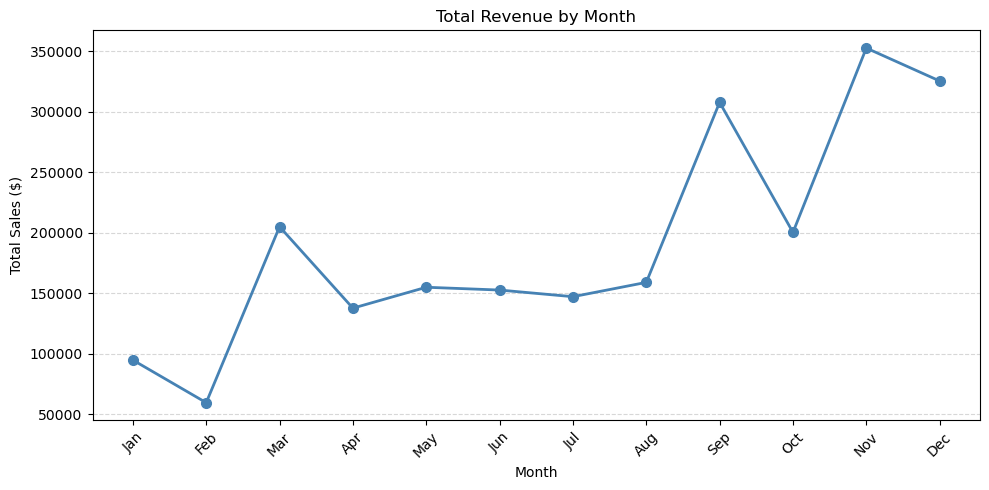

In [10]:
# Total revenue by month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month Name'] = pd.to_datetime(monthly['Month'], format='%m').dt.strftime('%b')

plt.figure(figsize=(10, 5))
plt.plot(monthly['Month Name'], monthly['Sales'], marker='o', color='steelblue', linewidth=2, markersize=7)
plt.title('Total Revenue by Month')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



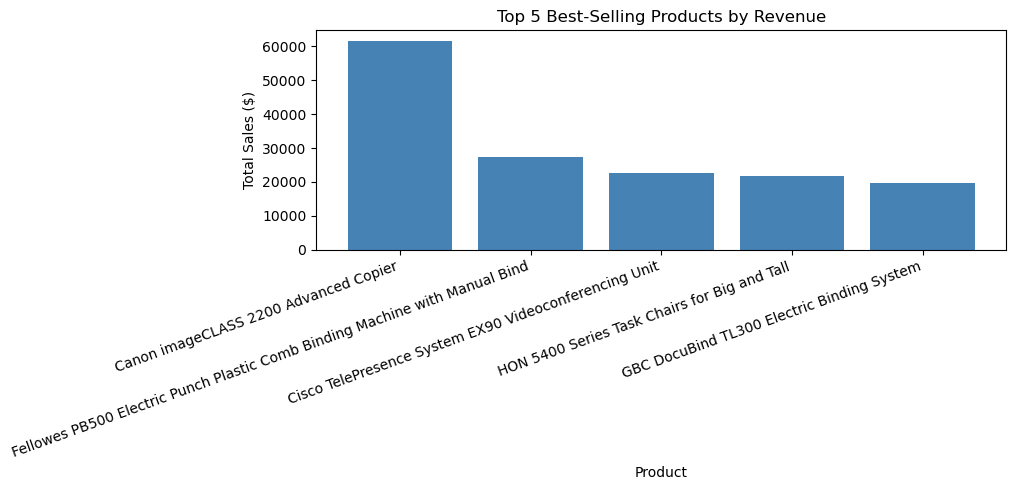

In [12]:
# Bar chart - Top 5 best selling products
top5 = df.groupby('Product Name')['Sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(10, 5))
plt.bar(top5['Product Name'], top5['Sales'], color='steelblue')
plt.title('Top 5 Best-Selling Products by Revenue')
plt.ylabel('Total Sales ($)')
plt.xlabel('Product')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()



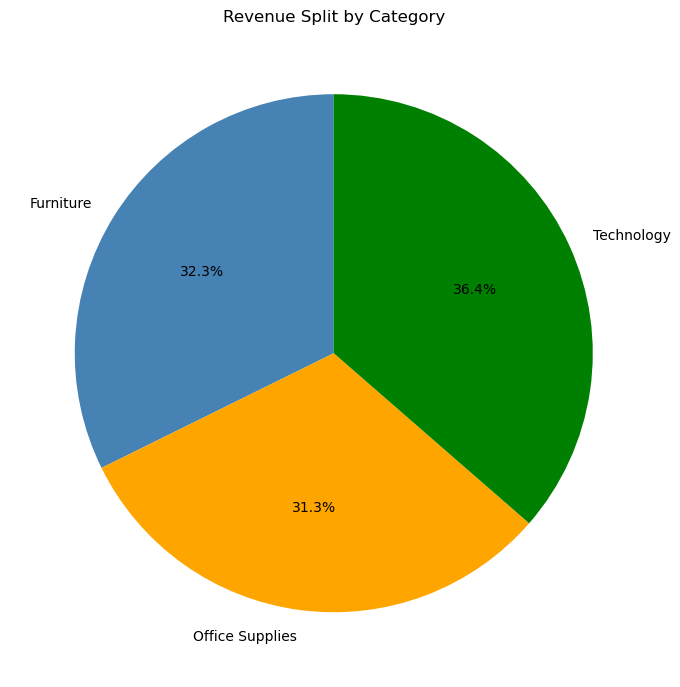

In [13]:
# Pie chart - Revenue split by category
cat_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(cat_sales, 
        labels=cat_sales.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=['steelblue', 'orange', 'green'])
plt.title('Revenue Split by Category')
plt.tight_layout()
plt.show()


# 5 Key Business Insights
Insight 1 — Technology is carrying the whole business
Walk into this store and you'd think it sells three things equally — but the numbers tell a different story. Technology alone brings in nearly two-thirds of all revenue. That's impressive, but it also means if tech sales sneeze, the whole business catches a cold. Furniture and Office Supplies need more love before this becomes a real problem.

Insight 2 — Nobody expected the USB Hub to win
Laptops, monitors, fancy chairs — and yet a humble USB Hub quietly outsold them all. It's the kind of product people grab without thinking twice, and apparently a lot of people are grabbing it. With everyone still juggling home offices and desk setups, bundling it with bigger purchases could turn a small win into a big one.

Insight 3 — Summer and year-end are where the money is
Sales come alive in June and again in October, then go quiet in February and September. It's almost like two separate shopping seasons packed into one year. The good news is those quiet months are predictable — which means there's a real opportunity to run targeted deals and promotions to wake them up.

Insight 4 — Office Supplies are being left behind
For a category that fills every desk in every office, contributing just 2.5% of revenue is a red flag. People clearly need pens, binders, and folders — they're just not buying them here. Whether it's the product selection, the pricing, or simply that nobody's promoting it, something needs to change in this corner of the business.

Insight 5 — The profit story is actually really good
Nearly 30 cents of profit on every dollar of revenue is genuinely strong — most retailers would be thrilled with half that. It means the business is well-run and pricing is working. The one thing worth watching is discounts — some orders are being discounted up to 30%, and over time that quietly chips away at margins that are otherwise healthy.